In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes, my_languages

from geometry import * 

eps = 1E-7
rcpsize = 16
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            ]

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=int)
relative_depths = layers.astype(float) / depths[modelB]

batch_shuffle = 0
centers_var = 'sem'
n_files = 21
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_var = 'sem'
zero_activations_list = [0]
center_A_flags = [0,1]

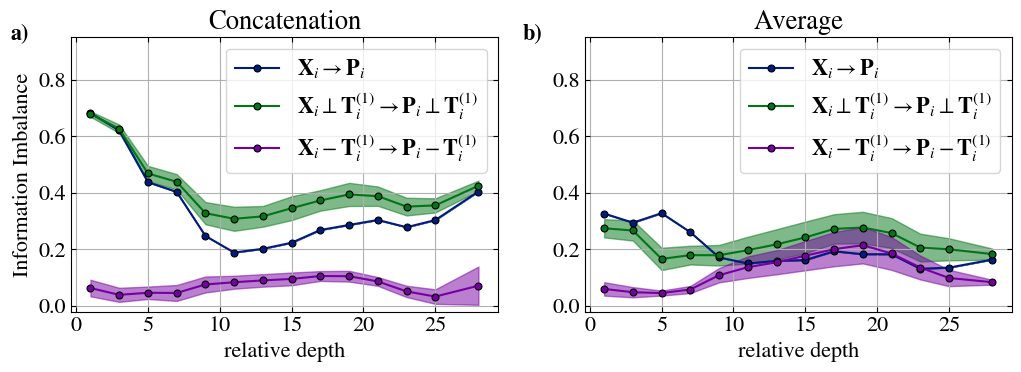

In [3]:
precision = 32

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
for avg_id,avg_tokens in enumerate(avg_flags):

  title = ' '
  plot_id = 0
  if avg_tokens:
    min_token_length = -1
  else:
    min_token_length = 3
  n_tokens = min_token_length

  for removal_method_id, removal_method in enumerate([None,'projection','subtraction']):
    inf_imb = np.zeros(shape=(len(my_languages),2,len(layers)))
    if removal_method_id == 2: removal_method_id += 1 # for colors in plot

    for center_A_id,center_A_flag in enumerate(center_A_flags):

        if center_A_id == 0 and removal_method != None: continue
        if removal_method == None and center_A_id != 0: continue
        center_B_flag = center_A_flag
        number_of_languages = 1 if center_A_flag != 0 else None
        for language_list_permutation in np.arange(len(my_languages),dtype=int):
          output_folder0 = makefolder(base=f'./results/',
                                      global_centering=0,
                                      spaces='AB',
                                      similarity_fn='normalized_L2_distance',
                                      precision=precision,
                                      language='english',
                                      data_var=data_var,
                                      modelA=modelA,
                                      modelB=modelB,
                                      match_var=match_var,
                                      n_files=n_files,
                                      min_token_length=min_token_length,
                                      )
          II_folder = makefolder(base=output_folder0,
                                            centers=centers_var,
                                            Nbits=Nbits,
                                            n_tokens=n_tokens,
                                            avg_tokens=avg_tokens,
                                            batch_shuffle=batch_shuffle,
                                            zero_activations=0,
                                            center_A_flag=center_A_flag,
                                            center_B_flag=center_B_flag,
                                            number_of_languages=number_of_languages,
                                            language_list_permutation=language_list_permutation if center_A_id > 0 else None,
                                            removal_method=removal_method,
                                            )
          inf_imb[language_list_permutation,:,:] = np.diagonal(np.load(II_folder + "II.npy"),axis1=1,axis2=2)
        
        color = colors[removal_method_id] 
        linestyle = '-'
        if avg_tokens:
          title = f'Average'
        else:
          title = f'Concatenation'

        label = ''
        if center_A_flag == 0:
          label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
        else:
          if removal_method == 'subtraction':
            label += r'$\mathbf{X}_i - \mathbf{T}_i^{(1)} \rightarrow \mathbf{P}_i - \mathbf{T}_i^{(1)}$'
          if removal_method == 'projection':
            label += r'$\mathbf{X}_i \perp \mathbf{T}_i^{(1)} \rightarrow \mathbf{P}_i \perp \mathbf{T}_i^{(1)} $'

        for II_index in range(1):
          ax[avg_id].plot(
              layers,
              inf_imb[:,II_index,:].mean(axis=0),
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              marker='o',                # circular marker
              markersize=5,              # tweakable size
              markerfacecolor=color,     # fill same as line
              markeredgecolor='black',   # cute black border
              markeredgewidth=0.8,       # adjust border thickness
          )

          ax[avg_id].fill_between(layers,
                          inf_imb[:,II_index,:].mean(axis=0) - inf_imb[:,II_index,:].std(axis=0),
                          inf_imb[:,II_index,:].mean(axis=0) + inf_imb[:,II_index,:].std(axis=0),
                          alpha=0.5,
                          color=color,
                          )
        plot_id += 1

  ax[avg_id].set_xlabel('relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  ax[avg_id].set_ylim(-0.02,.95)

  ax[avg_id].set_title(title)
  ax[avg_id].legend()

# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/proj_vs_sub_{modelA}.pdf', bbox_inches='tight')
plt.show()